# Практическая работа 1
## Работа с данными различных форматов: CSV, Excel, JSON, XML

In [25]:
import subprocess, sys

import warnings
warnings.filterwarnings('ignore')

required = ['pandas', 'openpyxl', 'lxml', 'xlrd', 'matplotlib']
for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Все зависимости установлены.')

Все зависимости установлены.


In [6]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lxml import etree

# Создание структуры директорий
for d in ['data/raw', 'data/processed', 'data/output']:
    os.makedirs(d, exist_ok=True)

print('Директории созданы:')
for root, dirs, files in os.walk('data'):
    level = root.replace('data', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')

Директории созданы:
data/
  raw/
  processed/
  output/


---
## Раздел 1. Работа с CSV-файлами

### 1.1 Создание и чтение CSV-файла

In [7]:
# Создание тестового CSV-файла с данными о продажах
csv_content = """date,product,category,price,quantity,region
2024-01-15,Laptop,Electronics,45000,2,Moscow
2024-01-16,Mouse,Accessories,800,5,St. Petersburg
2024-01-16,Keyboard,Accessories,1500,3,Moscow
2024-01-17,Monitor,Electronics,12000,1,Kazan
2024-01-18,Laptop,Electronics,48000,1,Moscow
2024-01-19,USB Cable,Accessories,300,10,St. Petersburg
2024-01-20,Tablet,Electronics,25000,2,Kazan
2024-01-21,Headphones,Accessories,3500,4,Moscow
2024-01-22,Webcam,Electronics,5500,2,Novosibirsk
2024-01-23,Printer,Electronics,15000,1,St. Petersburg
2024-01-24,SSD,Electronics,8000,3,Moscow
2024-01-25,Mouse Pad,Accessories,500,8,Kazan
2024-01-26,Laptop,Electronics,52000,1,Novosibirsk
2024-01-27,Speaker,Accessories,4200,2,Moscow
2024-01-28,Monitor,Electronics,14000,2,St. Petersburg
"""

with open('data/raw/sales_data.csv', 'w', encoding='utf-8') as f:
    f.write(csv_content)

print('Файл data/raw/sales_data.csv создан.')
print(f'Размер файла: {os.path.getsize("data/raw/sales_data.csv")} байт')

Файл data/raw/sales_data.csv создан.
Размер файла: 760 байт


In [8]:
# Чтение CSV-файла
df = pd.read_csv('data/raw/sales_data.csv', encoding='utf-8')

print('=== Первые 5 строк ===')
print(df.head())

print('\n=== Информация о данных ===')
df.info()

print('\n=== Базовые статистические характеристики ===')
print(df.describe())

print('\n=== Мода по категориям ===')
print('Самый частый продукт:', df['product'].mode()[0])
print('Самый частый регион:', df['region'].mode()[0])

print('\n=== Медианы числовых колонок ===')
print('Медиана цены:', df['price'].median())
print('Медиана количества:', df['quantity'].median())

=== Первые 5 строк ===
         date   product     category  price  quantity          region
0  2024-01-15    Laptop  Electronics  45000         2          Moscow
1  2024-01-16     Mouse  Accessories    800         5  St. Petersburg
2  2024-01-16  Keyboard  Accessories   1500         3          Moscow
3  2024-01-17   Monitor  Electronics  12000         1           Kazan
4  2024-01-18    Laptop  Electronics  48000         1          Moscow

=== Информация о данных ===
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   date      15 non-null     str  
 1   product   15 non-null     str  
 2   category  15 non-null     str  
 3   price     15 non-null     int64
 4   quantity  15 non-null     int64
 5   region    15 non-null     str  
dtypes: int64(2), str(4)
memory usage: 852.0 bytes

=== Базовые статистические характеристики ===
              price   quantity
count     15

### 1.2 Обработка и трансформация данных

In [9]:
# Конвертация столбца date в datetime
df['date'] = pd.to_datetime(df['date'])

# Создание нового столбца total_amount
df['total_amount'] = df['price'] * df['quantity']

print('=== DataFrame после трансформации ===')
print(df.head())
print(f'\nТип колонки date: {df["date"].dtype}')
print(f'Тип колонки total_amount: {df["total_amount"].dtype}')

# Группировка по категориям
category_sales = df.groupby('category')['total_amount'].sum()
print('\n=== Продажи по категориям ===')
print(category_sales)

# Фильтрация (продажи > 10000)
high_value_sales = df[df['total_amount'] > 10000]
print('\n=== Крупные продажи (total_amount > 10000) ===')
print(high_value_sales[['date', 'product', 'total_amount', 'region']])

=== DataFrame после трансформации ===
        date   product     category  price  quantity          region  \
0 2024-01-15    Laptop  Electronics  45000         2          Moscow   
1 2024-01-16     Mouse  Accessories    800         5  St. Petersburg   
2 2024-01-16  Keyboard  Accessories   1500         3          Moscow   
3 2024-01-17   Monitor  Electronics  12000         1           Kazan   
4 2024-01-18    Laptop  Electronics  48000         1          Moscow   

   total_amount  
0         90000  
1          4000  
2          4500  
3         12000  
4         48000  

Тип колонки date: datetime64[us]
Тип колонки total_amount: int64

=== Продажи по категориям ===
category
Accessories     37900
Electronics    330000
Name: total_amount, dtype: int64

=== Крупные продажи (total_amount > 10000) ===
         date     product  total_amount          region
0  2024-01-15      Laptop         90000          Moscow
3  2024-01-17     Monitor         12000           Kazan
4  2024-01-18      Lap

=== Статистика по регионам ===
                total_revenue  total_orders  avg_order_value
region                                                      
Kazan                   66000             3         22000.00
Moscow                 188900             6         31483.33
Novosibirsk             63000             2         31500.00
St. Petersburg          50000             4         12500.00


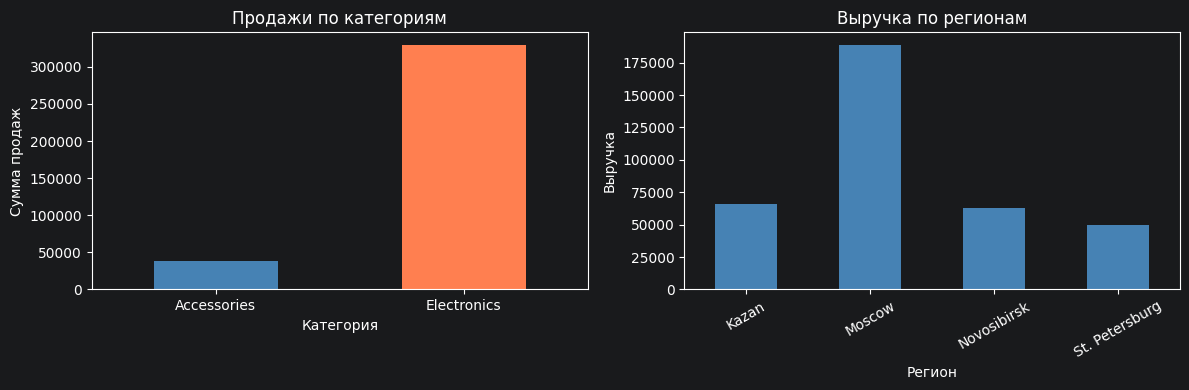

График сохранен в data/output/sales_charts.png


In [10]:
# Группировка по регионам
region_stats = df.groupby('region').agg(
    total_revenue=('total_amount', 'sum'),
    total_orders=('product', 'count'),
    avg_order_value=('total_amount', 'mean')
).round(2)
print('=== Статистика по регионам ===')
print(region_stats)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

category_sales.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Продажи по категориям')
axes[0].set_xlabel('Категория')
axes[0].set_ylabel('Сумма продаж')
axes[0].tick_params(axis='x', rotation=0)

region_stats['total_revenue'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Выручка по регионам')
axes[1].set_xlabel('Регион')
axes[1].set_ylabel('Выручка')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('data/output/sales_charts.png', dpi=100)
plt.show()
print('График сохранен в data/output/sales_charts.png')

### 1.3 Запись результатов в CSV

In [12]:
# Сохранение обработанных данных
# index=False - не сохранять индекс как отдельный столбец
df.to_csv('data/processed/sales_processed.csv', index=False, encoding='utf-8')

# Сохранение агрегированных данных
category_sales.to_csv('data/output/category_summary.csv')

# Сохранение с другим разделителем (TSV)
df.to_csv('data/output/sales_data.tsv', sep='\t', index=False, encoding='utf-8')

print('Файлы сохранены:')
for path in ['data/processed/sales_processed.csv',
             'data/output/category_summary.csv',
             'data/output/sales_data.tsv']:
    size = os.path.getsize(path)
    print(f'  {path}  ({size} байт)')

print('\n=== Ответы на контрольные вопросы по CSV ===')
print('1. Параметр sep= (или delimiter=) используется для указания разделителя.')
print('   Пример: pd.read_csv(file, sep=";", encoding="utf-8")')
print('2. Для кириллицы указывать encoding="utf-8" или encoding="cp1251".')
print('3. index=False при сохранении означает не записывать индекс DataFrame')
print('   как отдельный столбец в файле.')

Файлы сохранены:
  data/processed/sales_processed.csv  (858 байт)
  data/output/category_summary.csv  (59 байт)
  data/output/sales_data.tsv  (858 байт)

=== Ответы на контрольные вопросы по CSV ===
1. Параметр sep= (или delimiter=) используется для указания разделителя.
   Пример: pd.read_csv(file, sep=";", encoding="utf-8")
2. Для кириллицы указывать encoding="utf-8" или encoding="cp1251".
3. index=False при сохранении означает не записывать индекс DataFrame
   как отдельный столбец в файле.


---
## Раздел 2. Работа с Excel-файлами

### 2.1 Создание и запись Excel-файла

In [13]:
import pandas as pd

# Создание DataFrame для разных листов
sales_2023 = pd.DataFrame({
    'month': ['January', 'February', 'March'],
    'revenue': [150000, 180000, 165000],
    'costs': [90000, 100000, 95000]
})
sales_2023['profit'] = sales_2023['revenue'] - sales_2023['costs']

sales_2024 = pd.DataFrame({
    'month': ['January', 'February', 'March'],
    'revenue': [175000, 190000, 185000],
    'costs': [95000, 105000, 100000]
})
sales_2024['profit'] = sales_2024['revenue'] - sales_2024['costs']

# Запись в Excel с несколькими листами
with pd.ExcelWriter('data/output/annual_report.xlsx', engine='openpyxl') as writer:
    sales_2023.to_excel(writer, sheet_name='2023', index=False)
    sales_2024.to_excel(writer, sheet_name='2024', index=False)

print('Файл data/output/annual_report.xlsx создан.')
print('\n=== Данные 2023 ===')
print(sales_2023)
print('\n=== Данные 2024 ===')
print(sales_2024)

Файл data/output/annual_report.xlsx создан.

=== Данные 2023 ===
      month  revenue   costs  profit
0   January   150000   90000   60000
1  February   180000  100000   80000
2     March   165000   95000   70000

=== Данные 2024 ===
      month  revenue   costs  profit
0   January   175000   95000   80000
1  February   190000  105000   85000
2     March   185000  100000   85000


### 2.2 Чтение Excel-файлов

In [14]:
# Чтение конкретного листа
df_2023 = pd.read_excel('data/output/annual_report.xlsx', sheet_name='2023')
print('=== Данные за 2023 год ===')
print(df_2023)

# Чтение всех листов
all_sheets = pd.read_excel('data/output/annual_report.xlsx', sheet_name=None)
print('\n=== Все листы в файле ===')
for sheet_name, data in all_sheets.items():
    print(f'\nЛист: {sheet_name}')
    print(data)

# Чтение диапазона ячеек
df_range = pd.read_excel(
    'data/output/annual_report.xlsx',
    sheet_name='2023',
    usecols='A:B',
    nrows=2
)
print('\n=== Выборочное чтение (колонки A:B, 2 строки) ===')
print(df_range)

=== Данные за 2023 год ===
      month  revenue   costs  profit
0   January   150000   90000   60000
1  February   180000  100000   80000
2     March   165000   95000   70000

=== Все листы в файле ===

Лист: 2023
      month  revenue   costs  profit
0   January   150000   90000   60000
1  February   180000  100000   80000
2     March   165000   95000   70000

Лист: 2024
      month  revenue   costs  profit
0   January   175000   95000   80000
1  February   190000  105000   85000
2     March   185000  100000   85000

=== Выборочное чтение (колонки A:B, 2 строки) ===
      month  revenue
0   January   150000
1  February   180000


### 2.3 Продвинутая работа с Excel: сводная таблица

In [15]:
import openpyxl

# Создание сводной таблицы
pivot_data = pd.DataFrame({
    'date': ['2024-01'] * 3 + ['2024-02'] * 3,
    'product': ['A', 'B', 'C'] * 2,
    'sales': [100, 150, 200, 120, 160, 210]
})

pivot_table = pivot_data.pivot_table(
    values='sales',
    index='product',
    columns='date',
    aggfunc='sum'
)
print('=== Сводная таблица ===')
print(pivot_table)

# Сохранение с форматированием
with pd.ExcelWriter('data/output/pivot_report.xlsx', engine='openpyxl') as writer:
    pivot_table.to_excel(writer, sheet_name='Pivot')
    
    # Доступ к workbook для дополнительного форматирования
    workbook = writer.book
    worksheet = writer.sheets['Pivot']
    
    # Установка ширины столбцов
    for col in worksheet.columns:
        max_len = 0
        for cell in col:
            try:
                max_len = max(max_len, len(str(cell.value)))
            except Exception:
                pass
        worksheet.column_dimensions[col[0].column_letter].width = max_len + 4

print('\nСводная таблица сохранена в data/output/pivot_report.xlsx')

print('\n=== Ответы на контрольные вопросы по Excel ===')
print('1. По умолчанию engine="openpyxl" для .xlsx (xlrd только для старых .xls).')
print('2. Для чтения определенных столбцов: usecols="A:C" или usecols=[0,1,2].')
print('3. openpyxl читает/пишет .xlsx и поддерживает форматирование.')
print('   xlrd - только чтение старого формата .xls (до Excel 2003).')

=== Сводная таблица ===
date     2024-01  2024-02
product                  
A            100      120
B            150      160
C            200      210

Сводная таблица сохранена в data/output/pivot_report.xlsx

=== Ответы на контрольные вопросы по Excel ===
1. По умолчанию engine="openpyxl" для .xlsx (xlrd только для старых .xls).
2. Для чтения определенных столбцов: usecols="A:C" или usecols=[0,1,2].
3. openpyxl читает/пишет .xlsx и поддерживает форматирование.
   xlrd - только чтение старого формата .xls (до Excel 2003).


---
## Раздел 3. Работа с JSON-файлами

### 3.1 Простой JSON

In [16]:
import json
import pandas as pd

# Создание простого JSON
simple_data = {
    'employees': [
        {'id': 1, 'name': 'Ivanov', 'department': 'IT', 'salary': 80000},
        {'id': 2, 'name': 'Petrov', 'department': 'HR', 'salary': 65000},
        {'id': 3, 'name': 'Sidorov', 'department': 'IT', 'salary': 90000}
    ]
}

# Сохранение в JSON
with open('data/raw/employees.json', 'w', encoding='utf-8') as f:
    json.dump(simple_data, f, ensure_ascii=False, indent=2)

print('Файл data/raw/employees.json создан.')

# Чтение JSON с pandas
df_emp = pd.read_json('data/raw/employees.json')
# read_json с ключом 'employees' -- нормализация через json_normalize
df_emp = pd.json_normalize(simple_data['employees'])
print('\n=== Сотрудники (из JSON) ===')
print(df_emp)

Файл data/raw/employees.json создан.

=== Сотрудники (из JSON) ===
   id     name department  salary
0   1   Ivanov         IT   80000
1   2   Petrov         HR   65000
2   3  Sidorov         IT   90000


### 3.2 Вложенный JSON

In [17]:
# Вложенная структура
nested_json = {
    "company": "TechCorp",
    "employees": [
        {
            "id": 1,
            "name": "Ivanov",
            "contact": {
                "email": "ivanov@example.com",
                "phone": "+7-999-123-4567"
            },
            "projects": ["Project A", "Project B"]
        },
        {
            "id": 2,
            "name": "Petrov",
            "contact": {
                "email": "petrov@example.com",
                "phone": "+7-999-765-4321"
            },
            "projects": ["Project C"]
        }
    ]
}

# Сохранение
with open('data/raw/company.json', 'w', encoding='utf-8') as f:
    json.dump(nested_json, f, ensure_ascii=False, indent=2)

# Чтение с нормализацией
with open('data/raw/company.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# Нормализация вложенной структуры
df_normalized = pd.json_normalize(
    data['employees'],
    meta=['id', 'name'],
    record_path='projects',
    record_prefix='project_'
)
print('=== Нормализованные данные (по проектам) ===')
print(df_normalized)

# Нормализация с раскрытием contact
df_contact = pd.json_normalize(data['employees'], sep='_')
print('\n=== Нормализованные данные (с контактами) ===')
print(df_contact[['id', 'name', 'contact_email', 'contact_phone']])

=== Нормализованные данные (по проектам) ===
   project_0 id    name
0  Project A  1  Ivanov
1  Project B  1  Ivanov
2  Project C  2  Petrov

=== Нормализованные данные (с контактами) ===
   id    name       contact_email    contact_phone
0   1  Ivanov  ivanov@example.com  +7-999-123-4567
1   2  Petrov  petrov@example.com  +7-999-765-4321


### 3.3 Различные ориентации JSON

In [18]:
# Создание DataFrame
df_orient = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Charlie'],
    'age': [25, 30, 35],
    'city': ['Moscow', 'SPb', 'Kazan']
})

# Сохранение в разных форматах
df_orient.to_json('data/output/records.json', orient='records', force_ascii=False)
df_orient.to_json('data/output/index.json', orient='index', force_ascii=False)
df_orient.to_json('data/output/columns.json', orient='columns', force_ascii=False)
df_orient.to_json('data/output/values.json', orient='values', force_ascii=False)

# Чтение и сравнение
print('=== Records format (список словарей) ===')
with open('data/output/records.json', 'r') as f:
    print(f.read())

print('\n=== Columns format (словарь колонок) ===')
with open('data/output/columns.json', 'r') as f:
    print(f.read())

print('\n=== Чтение обратно в DataFrame ===')
df_back = pd.read_json('data/output/records.json', orient='records')
print(df_back)

print('\n=== Ответы на контрольные вопросы по JSON ===')
print('1. Параметры orient: records, index, columns, values, split, table.')
print('2. pd.json_normalize() разворачивает вложенные структуры JSON')
print('   в плоский DataFrame, разделяя ключи указанным separator.')
print('3. Для нестандартной кодировки: open(file, encoding="cp1251") + json.load().')

=== Records format (список словарей) ===
[{"name":"Alice","age":25,"city":"Moscow"},{"name":"Bob","age":30,"city":"SPb"},{"name":"Charlie","age":35,"city":"Kazan"}]

=== Columns format (словарь колонок) ===
{"name":{"0":"Alice","1":"Bob","2":"Charlie"},"age":{"0":25,"1":30,"2":35},"city":{"0":"Moscow","1":"SPb","2":"Kazan"}}

=== Чтение обратно в DataFrame ===
      name  age    city
0    Alice   25  Moscow
1      Bob   30     SPb
2  Charlie   35   Kazan

=== Ответы на контрольные вопросы по JSON ===
1. Параметры orient: records, index, columns, values, split, table.
2. pd.json_normalize() разворачивает вложенные структуры JSON
   в плоский DataFrame, разделяя ключи указанным separator.
3. Для нестандартной кодировки: open(file, encoding="cp1251") + json.load().


---
## Раздел 4. Работа с XML-файлами

### 4.1 Простой XML

In [19]:
import pandas as pd

# Создание простого XML
xml_data = """<?xml version="1.0" encoding="utf-8"?>
<catalog>
    <book>
        <author>McKinney</author>
        <year>2022</year>
        <price>1500</price>
    </book>
    <book>
        <author>Vanderplas</author>
        <year>2023</year>
        <price>1200</price>
    </book>
    <book>
        <author>Smith</author>
        <year>2024</year>
        <price>1800</price>
    </book>
</catalog>
"""

# Сохранение XML
with open('data/raw/catalog.xml', 'w', encoding='utf-8') as f:
    f.write(xml_data)

# Чтение XML через pandas
df_xml = pd.read_xml('data/raw/catalog.xml', xpath='//book')
print('=== Каталог книг ===')
print(df_xml)

# Базовая обработка
df_xml['price'] = df_xml['price'].astype(int)
avg_price = df_xml['price'].mean()
print(f'\nСредняя цена книг: {avg_price:.2f}')

=== Каталог книг ===
       author  year  price
0    McKinney  2022   1500
1  Vanderplas  2023   1200
2       Smith  2024   1800

Средняя цена книг: 1500.00


### 4.2 XML с атрибутами

In [20]:
# XML с атрибутами
xml_with_attrs = """<?xml version="1.0" encoding="utf-8"?>
<products>
    <product id="1" category="electronics">
        <name>Laptop</name>
        <price currency="RUB">45000</price>
        <stock>15</stock>
    </product>
    <product id="2" category="accessories">
        <name>Mouse</name>
        <price currency="RUB">800</price>
        <stock>50</stock>
    </product>
    <product id="3" category="electronics">
        <name>Monitor</name>
        <price currency="RUB">12000</price>
        <stock>8</stock>
    </product>
</products>
"""

with open('data/raw/products.xml', 'w', encoding='utf-8') as f:
    f.write(xml_with_attrs)

# Чтение с атрибутами через pandas
df_prod = pd.read_xml('data/raw/products.xml')
print('=== Продукты (чтение через pandas) ===')
print(df_prod)

# Запись обратно в XML
df_prod.to_xml(
    'data/output/products_modified.xml',
    index=False,
    root_name='products',
    row_name='product'
)
print('\nФайл products_modified.xml сохранен.')

=== Продукты (чтение через pandas) ===
   id     category     name  price  stock
0   1  electronics   Laptop  45000     15
1   2  accessories    Mouse    800     50
2   3  electronics  Monitor  12000      8

Файл products_modified.xml сохранен.


### 4.3 Парсинг сложного XML с помощью lxml

In [21]:
from lxml import etree

# Чтение XML для более сложной обработки
tree = etree.parse('data/raw/products.xml')
root = tree.getroot()

# Извлечение данных с помощью XPath
products = []
for product in root.xpath('//product'):
    products.append({
        'id': product.get('id'),
        'category': product.get('category'),
        'name': product.find('name').text,
        'price': int(product.find('price').text),
        'currency': product.find('price').get('currency'),
        'stock': int(product.find('stock').text)
    })

df_lxml = pd.DataFrame(products)
print('=== Продукты (через lxml + XPath) ===')
print(df_lxml)

# Фильтрация и анализ
electronics = df_lxml[df_lxml['category'] == 'electronics']
print(f'\nОбщая стоимость электроники на складе: {(electronics["price"] * electronics["stock"]).sum()}')

print('\n=== Ответы на контрольные вопросы по XML ===')
print('1. Параметр xpath= в pd.read_xml() указывает XPath-выражение для узлов.')
print('2. pd.read_xml() проще, но не обрабатывает атрибуты автоматически.')
print('   lxml дает полный контроль: атрибуты, пространства имен, навигация.')
print('3. Для пространств имен в lxml: etree.parse() + namespaces={"ns": "uri"}')
print('   в xpath() или использовать Clark notation {uri}element.')

=== Продукты (через lxml + XPath) ===
  id     category     name  price currency  stock
0  1  electronics   Laptop  45000      RUB     15
1  2  accessories    Mouse    800      RUB     50
2  3  electronics  Monitor  12000      RUB      8

Общая стоимость электроники на складе: 771000

=== Ответы на контрольные вопросы по XML ===
1. Параметр xpath= в pd.read_xml() указывает XPath-выражение для узлов.
2. pd.read_xml() проще, но не обрабатывает атрибуты автоматически.
   lxml дает полный контроль: атрибуты, пространства имен, навигация.
3. Для пространств имен в lxml: etree.parse() + namespaces={"ns": "uri"}
   в xpath() или использовать Clark notation {uri}element.


---
## Раздел 5. Интеграция форматов

### 5.1 Класс DataConverter

In [22]:
import pandas as pd
import json
import os

class DataConverter:
    """Класс для конвертации данных между форматами."""

    def __init__(self, input_path: str):
        self.input_path = input_path
        self.df = None
        self._ext = os.path.splitext(input_path)[1].lower()

    def read_data(self) -> pd.DataFrame:
        """Чтение данных в зависимости от формата."""
        readers = {
            '.csv': lambda p: pd.read_csv(p, encoding='utf-8'),
            '.xlsx': lambda p: pd.read_excel(p),
            '.xls': lambda p: pd.read_excel(p),
            '.json': lambda p: pd.read_json(p),
            '.xml': lambda p: pd.read_xml(p),
        }
        if self._ext not in readers:
            raise ValueError(f'Неподдерживаемый формат: {self._ext}')
        self.df = readers[self._ext](self.input_path)
        print(f'Прочитано {len(self.df)} строк из {self.input_path}')
        return self.df

    def convert_to_all(self, output_dir: str) -> dict:
        """Конвертация в все поддерживаемые форматы."""
        if self.df is None:
            self.read_data()
        os.makedirs(output_dir, exist_ok=True)
        base = os.path.splitext(os.path.basename(self.input_path))[0]
        results = {}

        # CSV
        path_csv = os.path.join(output_dir, f'{base}.csv')
        self.df.to_csv(path_csv, index=False, encoding='utf-8')
        results['csv'] = path_csv

        # Excel
        path_xlsx = os.path.join(output_dir, f'{base}.xlsx')
        self.df.to_excel(path_xlsx, index=False)
        results['xlsx'] = path_xlsx

        # JSON
        path_json = os.path.join(output_dir, f'{base}.json')
        self.df.to_json(path_json, orient='records', force_ascii=False, indent=2)
        results['json'] = path_json

        # XML
        path_xml = os.path.join(output_dir, f'{base}.xml')
        self.df.to_xml(path_xml, index=False)
        results['xml'] = path_xml

        return results

# Использование конвертера
converter = DataConverter('data/raw/sales_data.csv')
converter.read_data()
results = converter.convert_to_all('data/output/converted')

print('\n=== Результаты конвертации ===')
for fmt, path in results.items():
    size = os.path.getsize(path)
    print(f'  {fmt}: {path}  ({size} байт)')

Прочитано 15 строк из data/raw/sales_data.csv

=== Результаты конвертации ===
  csv: data/output/converted/sales_data.csv  (760 байт)
  xlsx: data/output/converted/sales_data.xlsx  (5490 байт)
  json: data/output/converted/sales_data.json  (2248 байт)
  xml: data/output/converted/sales_data.xml  (2975 байт)


### 5.2 ETL-процесс с множественными источниками

In [23]:
import pandas as pd
import json
import os

def etl_process():
    """Полный ETL-процесс с данными из разных источников."""

    # === EXTRACT ===
    print('=== EXTRACT PHASE ===')

    # CSV: данные о продажах
    df_sales = pd.read_csv('data/raw/sales_data.csv', encoding='utf-8')
    print(f'CSV (продажи): {len(df_sales)} строк')

    # JSON: данные о сотрудниках
    with open('data/raw/employees.json', 'r', encoding='utf-8') as f:
        emp_data = json.load(f)
    df_employees = pd.json_normalize(emp_data['employees'])
    print(f'JSON (сотрудники): {len(df_employees)} строк')

    # XML: данные о продуктах
    df_products = pd.read_xml('data/raw/products.xml')
    print(f'XML (продукты): {len(df_products)} строк')

    # === TRANSFORM ===
    print('\n=== TRANSFORM PHASE ===')

    # Агрегация продаж
    df_sales['date'] = pd.to_datetime(df_sales['date'])
    df_sales['total_amount'] = df_sales['price'] * df_sales['quantity']

    sales_agg = df_sales.groupby('category').agg(
        total_revenue=('total_amount', 'sum'),
        total_orders=('product', 'count'),
        avg_price=('price', 'mean')
    ).round(2).reset_index()

    print('Агрегированные продажи по категориям:')
    print(sales_agg)

    # Добавление информации о средней зарплате
    avg_salary = df_employees['salary'].mean()
    sales_agg['note'] = f'avg_salary={avg_salary:.0f}'
    print('\nДанные агрегированы')

    # === LOAD ===
    print('\n=== LOAD PHASE ===')

    result_dir = 'data/output/etl_results'
    os.makedirs(result_dir, exist_ok=True)

    # Сохранение в разных форматах
    sales_agg.to_csv(f'{result_dir}/sales_summary.csv', index=False)
    sales_agg.to_excel(f'{result_dir}/sales_summary.xlsx', index=False)
    sales_agg.to_json(f'{result_dir}/sales_summary.json', orient='records',
                      force_ascii=False, indent=2)

    print(f'Результаты сохранены в {result_dir}/')
    for f in os.listdir(result_dir):
        fpath = os.path.join(result_dir, f)
        print(f'  {f}  ({os.path.getsize(fpath)} байт)')

    return sales_agg

result = etl_process()

=== EXTRACT PHASE ===
CSV (продажи): 15 строк
JSON (сотрудники): 3 строк
XML (продукты): 3 строк

=== TRANSFORM PHASE ===
Агрегированные продажи по категориям:
      category  total_revenue  total_orders  avg_price
0  Accessories          37900             6    1800.00
1  Electronics         330000             9   24944.44

Данные агрегированы

=== LOAD PHASE ===
Результаты сохранены в data/output/etl_results/
  sales_summary.csv  (142 байт)
  sales_summary.xlsx  (4981 байт)
  sales_summary.json  (289 байт)


### 5.3 Бенчмаркинг форматов

=== Результаты бенчмаркинга ===
 n_rows format  write_time  read_time  file_size_kb
   1000    csv      0.0094     0.0037          51.7
   1000   xlsx      0.1014     0.0774          43.0
   1000   json      0.0032     0.0052          85.5
   5000    csv      0.0167     0.0071         267.2
   5000   xlsx      0.5842     0.4277         195.6
   5000   json      0.0088     0.0144         436.2
  10000    csv      0.0358     0.0116         536.6
  10000   xlsx      1.0647     0.5973         386.5
  10000   json      0.0132     0.0229         874.6


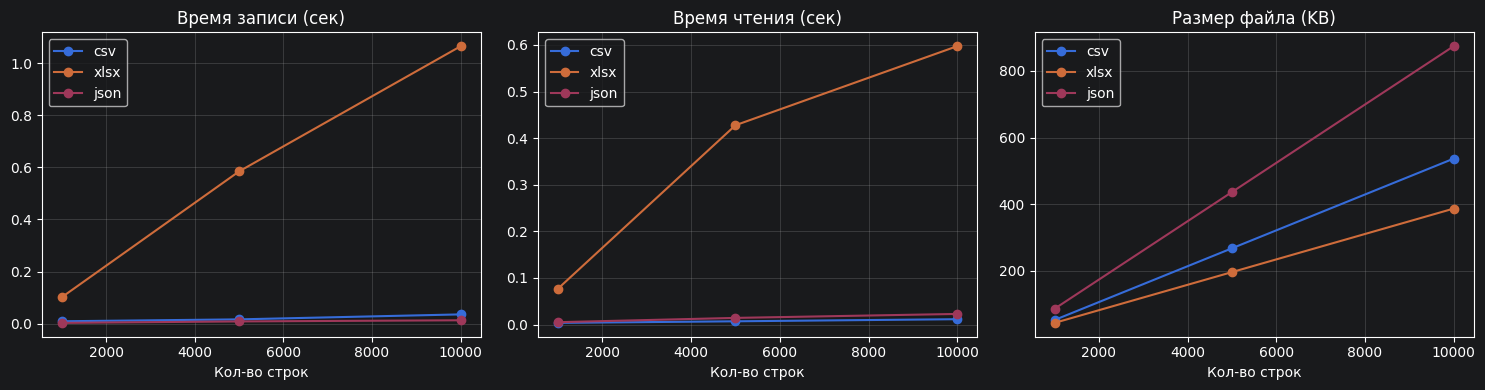

График бенчмаркинга сохранен в data/output/benchmark_chart.png


In [26]:
import time
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def benchmark_formats(n_rows_list=None):
    """Сравнение производительности форматов записи/чтения."""
    if n_rows_list is None:
        n_rows_list = [1000, 5000, 10000]

    results = []
    bench_dir = 'data/output/benchmark'
    os.makedirs(bench_dir, exist_ok=True)

    for n in n_rows_list:
        # Генерация данных
        np.random.seed(42)
        df_test = pd.DataFrame({
            'id': range(n),
            'name': [f'item_{i}' for i in range(n)],
            'value': np.random.uniform(0, 1000, n),
            'category': np.random.choice(['A', 'B', 'C'], n),
            'date': pd.date_range('2024-01-01', periods=n, freq='h')
        })

        for fmt in ['csv', 'xlsx', 'json']:
            fpath = f'{bench_dir}/test_{n}.{fmt}'

            # Запись
            t0 = time.time()
            if fmt == 'csv':
                df_test.to_csv(fpath, index=False)
            elif fmt == 'xlsx':
                df_test.to_excel(fpath, index=False)
            elif fmt == 'json':
                df_test.to_json(fpath, orient='records')
            write_time = time.time() - t0

            # Чтение
            t0 = time.time()
            if fmt == 'csv':
                _ = pd.read_csv(fpath)
            elif fmt == 'xlsx':
                _ = pd.read_excel(fpath)
            elif fmt == 'json':
                _ = pd.read_json(fpath)
            read_time = time.time() - t0

            file_size = os.path.getsize(fpath)
            results.append({
                'n_rows': n,
                'format': fmt,
                'write_time': round(write_time, 4),
                'read_time': round(read_time, 4),
                'file_size_kb': round(file_size / 1024, 1)
            })

    df_bench = pd.DataFrame(results)
    print('=== Результаты бенчмаркинга ===')
    print(df_bench.to_string(index=False))

    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, metric, title in zip(
        axes,
        ['write_time', 'read_time', 'file_size_kb'],
        ['Время записи (сек)', 'Время чтения (сек)', 'Размер файла (KB)']
    ):
        for fmt in ['csv', 'xlsx', 'json']:
            sub = df_bench[df_bench['format'] == fmt]
            ax.plot(sub['n_rows'], sub[metric], marker='o', label=fmt)
        ax.set_title(title)
        ax.set_xlabel('Кол-во строк')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('data/output/benchmark_chart.png', dpi=100)
    plt.show()
    print('График бенчмаркинга сохранен в data/output/benchmark_chart.png')
    return df_bench

df_bench = benchmark_formats()

---
## Раздел 6. Практическое применение: система обработки данных для e-commerce

In [27]:
import pandas as pd
import json
import os

# 1. Загрузка данных о заказах из CSV
df_orders = pd.read_csv('data/raw/sales_data.csv', encoding='utf-8')
df_orders['date'] = pd.to_datetime(df_orders['date'])
df_orders['total_amount'] = df_orders['price'] * df_orders['quantity']
print(f'Загружено заказов: {len(df_orders)}')

# 2. Загрузка информации о продуктах из Excel
# Создадим Excel-файл с данными о продуктах
products_df = pd.DataFrame({
    'product': ['Laptop', 'Mouse', 'Keyboard', 'Monitor', 'USB Cable',
                'Tablet', 'Headphones', 'Webcam', 'Printer', 'SSD',
                'Mouse Pad', 'Speaker'],
    'brand': ['BrandA', 'BrandB', 'BrandB', 'BrandC', 'BrandD',
              'BrandA', 'BrandE', 'BrandC', 'BrandF', 'BrandG',
              'BrandD', 'BrandE'],
    'weight_kg': [2.1, 0.1, 0.5, 5.0, 0.05,
                  0.6, 0.3, 0.2, 8.0, 0.07,
                  0.15, 0.8]
})
products_df.to_excel('data/raw/products_catalog.xlsx', index=False)
df_products_cat = pd.read_excel('data/raw/products_catalog.xlsx')
print(f'Загружено продуктов: {len(df_products_cat)}')

# 3. Загрузка данных о клиентах из JSON
customers_data = {
    'customers': [
        {'id': 'C001', 'name': 'Ivanov', 'tier': 'gold', 'region': 'Moscow'},
        {'id': 'C002', 'name': 'Petrov', 'tier': 'silver', 'region': 'St. Petersburg'},
        {'id': 'C003', 'name': 'Sidorov', 'tier': 'bronze', 'region': 'Kazan'},
        {'id': 'C004', 'name': 'Kozlov', 'tier': 'gold', 'region': 'Novosibirsk'},
    ]
}
with open('data/raw/customers.json', 'w', encoding='utf-8') as f:
    json.dump(customers_data, f, ensure_ascii=False, indent=2)
df_customers = pd.json_normalize(customers_data['customers'])
print(f'Загружено клиентов: {len(df_customers)}')

# 4. Объединение данных
df_combined = df_orders.merge(df_products_cat, on='product', how='left')
df_combined = df_combined.merge(
    df_customers[['region', 'tier']],
    on='region',
    how='left'
)
print(f'\nОбъединенный датасет: {len(df_combined)} строк')
print(df_combined.head())

# 5. Аналитика
print('\n=== Топ-10 продуктов по выручке ===')
top10 = df_combined.groupby('product')['total_amount'].sum().sort_values(ascending=False).head(10)
print(top10)

print('\n=== Распределение по регионам ===')
region_dist = df_combined.groupby('region').agg(
    orders=('product', 'count'),
    revenue=('total_amount', 'sum')
)
print(region_dist)

# 6. Сохранение результатов в Excel с несколькими листами
with pd.ExcelWriter('data/output/ecommerce_report.xlsx', engine='openpyxl') as writer:
    df_combined.to_excel(writer, sheet_name='All Data', index=False)
    top10.to_excel(writer, sheet_name='Top Products')
    region_dist.to_excel(writer, sheet_name='Regions')
print('\nОтчет сохранен в data/output/ecommerce_report.xlsx')

# 7. JSON-отчет для веб-дашборда
dashboard_report = {
    'total_revenue': float(df_combined['total_amount'].sum()),
    'total_orders': int(len(df_combined)),
    'avg_order_value': float(df_combined['total_amount'].mean()),
    'top_products': top10.reset_index().rename(
        columns={'total_amount': 'revenue'}).to_dict(orient='records'),
    'regions': region_dist.reset_index().to_dict(orient='records')
}

with open('data/output/dashboard_report.json', 'w', encoding='utf-8') as f:
    json.dump(dashboard_report, f, ensure_ascii=False, indent=2)
print('JSON-отчет для дашборда сохранен в data/output/dashboard_report.json')

Загружено заказов: 15
Загружено продуктов: 12
Загружено клиентов: 4

Объединенный датасет: 15 строк
        date   product     category  price  quantity          region  \
0 2024-01-15    Laptop  Electronics  45000         2          Moscow   
1 2024-01-16     Mouse  Accessories    800         5  St. Petersburg   
2 2024-01-16  Keyboard  Accessories   1500         3          Moscow   
3 2024-01-17   Monitor  Electronics  12000         1           Kazan   
4 2024-01-18    Laptop  Electronics  48000         1          Moscow   

   total_amount   brand  weight_kg    tier  
0         90000  BrandA        2.1    gold  
1          4000  BrandB        0.1  silver  
2          4500  BrandB        0.5    gold  
3         12000  BrandC        5.0  bronze  
4         48000  BrandA        2.1    gold  

=== Топ-10 продуктов по выручке ===
product
Laptop        190000
Tablet         50000
Monitor        40000
SSD            24000
Printer        15000
Headphones     14000
Webcam         11000
Speak